# Hand Digit Recognition using Convolutional Neural Networks (CNNs)

### Install the required libraries

In [9]:
# pip install tensorflow matplotlib numpy

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt



## Load MNIST dataset


In [11]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

## # Normalize pixel values (0–255 → 0–1)

In [12]:
train_images = train_images.reshape(
    (train_images.shape[0], 28 * 28)).astype('float32') / 255
test_images = test_images.reshape(
    (test_images.shape[0], 28 * 28)).astype('float32') / 255


## Build model

In [13]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(28 * 28,)),
    Dense(10, activation='softmax')
])

# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

C:\Users\PANDIT JI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile model


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Train model


In [15]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9281 - loss: 0.2562
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9674 - loss: 0.1093
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9776 - loss: 0.0741
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9829 - loss: 0.0561
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9864 - loss: 0.0431


# Evaluate


In [16]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9742 - loss: 0.0826
Test accuracy: 0.9742000102996826



# Save model

In [17]:

model.save("mnist_model.h5")

## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted: 7
Actual: 7


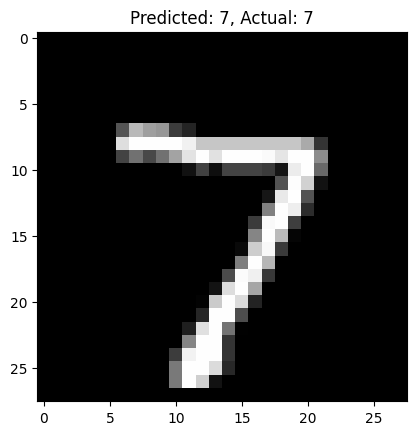

In [23]:
# Load model
model = tf.keras.models.load_model("mnist_model.h5")

# Load test data
(_, _), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
x_test = test_images.reshape((test_images.shape[0], 28 * 28)).astype('float32') / 255.0

# Predict one sample
index = 0
prediction = model.predict(np.expand_dims(x_test[index], axis=0))

print("Predicted:", np.argmax(prediction))
print("Actual:", test_labels[index])

# Visualize the original 28x28 image
plt.imshow(test_images[index], cmap='gray')
plt.title(f"Predicted: {np.argmax(prediction)}, Actual: {test_labels[index]}")
plt.show()